# Exploring segmenting tailings areas in hyperspectral imagery

What we want to know: 
* Can we use manually identified instances of tailings areas to find others?
* Can we use a similar method to ID the water in tailings areas, maybe combined with some morphological/geometric operators?

In [2]:
### Path adjustment so internal functions can be imported

import sys
import os # for file handling

# Add the parent directory to the system path
parent_dir = os.path.abspath(os.path.join(sys.path[0], ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print("Parent directory added to sys.path:", parent_dir)    

Parent directory added to sys.path: /Users/rmanzuk/Princeton Dropbox/Ryan Manzuk/code/hyperspectral_u_sensing


In [3]:
### Package imports
import geopandas as gpd # for handling geospatial data
import h5py # the hyperspectral data is in hdf5 format
from rasterio.features import rasterize # to make masks from shapefiles
import matplotlib.pyplot as plt # gotta plot
import numpy as np # for numerical operations
from shapely import box 
from sklearn.decomposition import PCA
import rasterio as rio # for reading/writing geospatial raster data


In [4]:
### Function imports

import hyperspectral_u_sensing.processing.tanager_file_handling as tanager_file_handling
import hyperspectral_u_sensing.processing.hyperspectral_corrections as hyperspectral_corrections

In [5]:
### Load in tailings shapefiles

# set a base path
base_path = '/Users/rmanzuk/Princeton Dropbox/Ryan Manzuk/drc_hyperspectral'

# sub paths for the tailings and water shapefiles
tailings_subpath = 'traced_polygons/tailings_areas/tailings_areas.shp'
water_subpath = 'traced_polygons/tailings_water/tailings_water.shp'

# load the shapefiles
tailings_gdf = gpd.read_file(os.path.join(base_path, tailings_subpath))
water_gdf = gpd.read_file(os.path.join(base_path, water_subpath))

# check the shapefiles as an output
print(tailings_gdf.head())
print(water_gdf.head())

     id                                           geometry
0  None  POLYGON ((25.32286 -10.76923, 25.32298 -10.767...
1  None  POLYGON ((25.40389 -10.76354, 25.40381 -10.763...
2  None  POLYGON ((25.31103 -10.74595, 25.31204 -10.745...
3  None  POLYGON ((25.31398 -10.73422, 25.3148 -10.7334...
4  None  POLYGON ((25.39696 -10.7036, 25.39694 -10.7023...
   id                                           geometry
0 NaN  POLYGON ((25.41267 -10.7654, 25.41273 -10.7646...
1 NaN  POLYGON ((25.31407 -10.73413, 25.31496 -10.733...
2 NaN  POLYGON ((25.30671 -10.74802, 25.30943 -10.746...
3 NaN  POLYGON ((25.40141 -10.69845, 25.40138 -10.697...
4 NaN  POLYGON ((25.37804 -10.70044, 25.37869 -10.699...


In [6]:
### Load in the hyperspectral data

# sub path for the kolwezi hyperspectral data
im_subpath = 'tanager_ims_drc/commus-order_tan-ortho-radiance_20250625'
im_path = os.path.join(base_path, im_subpath)

# search through the subdirectories for hdf5 file and the metadata.json file
scene_path, metadata_path = tanager_file_handling.find_subpaths(im_path)

# load the hyperspectral data
scene_file = h5py.File(scene_path, 'r')
scene_key = tanager_file_handling.scene_key(True)
rad_array, rad_attrs = tanager_file_handling.load_radiance(scene_file, scene_key)

# print the shape of the radiance array as a check
print("Radiance array shape:", rad_array.shape)
print("Radiance array attributes:", rad_attrs)

Radiance array shape: (426, 658, 775)
Radiance array attributes: {'Unit': 'W/(m^2 sr um)', '_FillValue': np.float32(-9999.0), 'applied_radiometric_coefficients': array([0.24117877, 0.19664247, 0.12794702, 0.10599381, 0.0785861 ,
       0.06810818, 0.05935678, 0.04755091, 0.04190101, 0.03722739,
       0.03394626, 0.0303052 , 0.02826379, 0.02598685, 0.02387025,
       0.02336355, 0.02251674, 0.02208806, 0.02204469, 0.02220925,
       0.02168082, 0.02049176, 0.01993347, 0.01987995, 0.01913034,
       0.01838925, 0.01796245, 0.01744622, 0.01674083, 0.01709536,
       0.01676122, 0.01611635, 0.01537274, 0.01469532, 0.0143942 ,
       0.01404121, 0.01360779, 0.01338364, 0.01328742, 0.01275896,
       0.01256888, 0.01229605, 0.01184709, 0.01151312, 0.01140921,
       0.01112384, 0.01085087, 0.01073875, 0.01054627, 0.01030221,
       0.0100322 , 0.01017956, 0.01043109, 0.01048737, 0.01056168,
       0.01062509, 0.01038046, 0.01180799, 0.01294908, 0.01158617,
       0.01024127, 0.01051945, 0.0

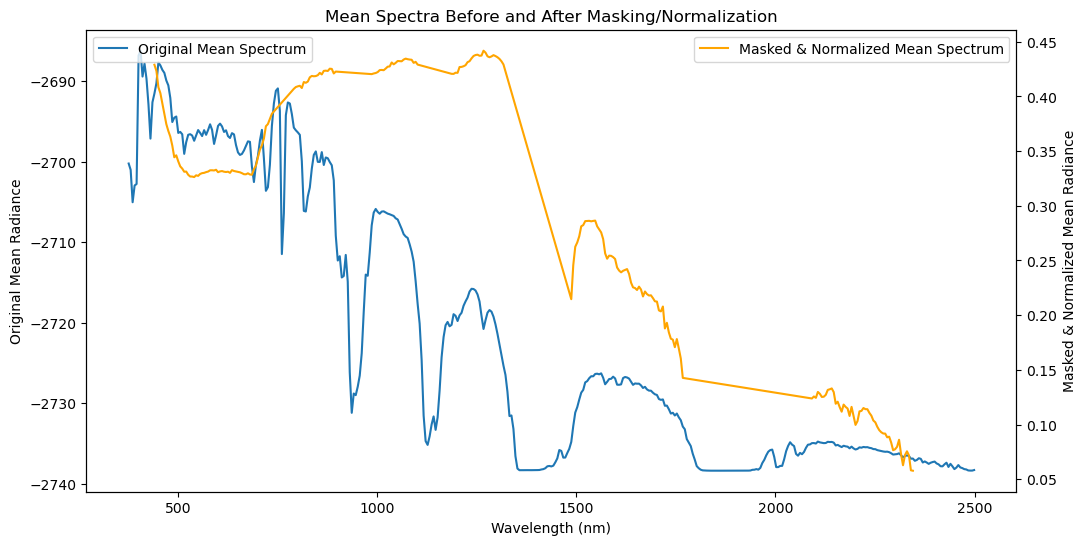

In [7]:
### make some adjustments to the radiance array to get rid of the bad bands (most atmospherically affected) a mask out no data values

# need the mean spectrum to feed into the band function
mean_spectrum = np.mean(rad_array, axis=(1,2))

# make the bad band mask and associated bits
bad_mask = hyperspectral_corrections.tanager_bad_band_mask(rad_attrs['wavelengths'],
                          spectrum=mean_spectrum,
                          pad_nm=20)

good_mask = ~bad_mask
bad_indices = np.where(bad_mask)[0].tolist()
rad_array_masked = rad_array[good_mask]
wavelengths_masked = rad_attrs['wavelengths'][good_mask]

# take care of the no data values
no_data_val = rad_attrs['_FillValue']
no_data_mask = np.any(rad_array_masked == no_data_val, axis=0)
rad_array_masked[:, no_data_mask] = np.nan

# use the function to max normalize each band
rad_array_masked = hyperspectral_corrections.band_max_norm(rad_array_masked)

# and make a new mean spectrum
normalized_mean_spectrum = np.nanmean(rad_array_masked, axis=(1,2))

# plot both mean spectra to check on a double y axis plot
plt.figure(figsize=(12, 6))
plt.plot(rad_attrs['wavelengths'], mean_spectrum, label='Original Mean Spectrum')
# double y axis plot
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.plot(wavelengths_masked, normalized_mean_spectrum, color='orange', label='Masked & Normalized Mean Spectrum')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Original Mean Radiance')
ax2.set_ylabel('Masked & Normalized Mean Radiance')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Mean Spectra Before and After Masking/Normalization')
plt.show()

Explained variance ratio: [0.8333219  0.11920252 0.03312342 0.00821118 0.00322742]


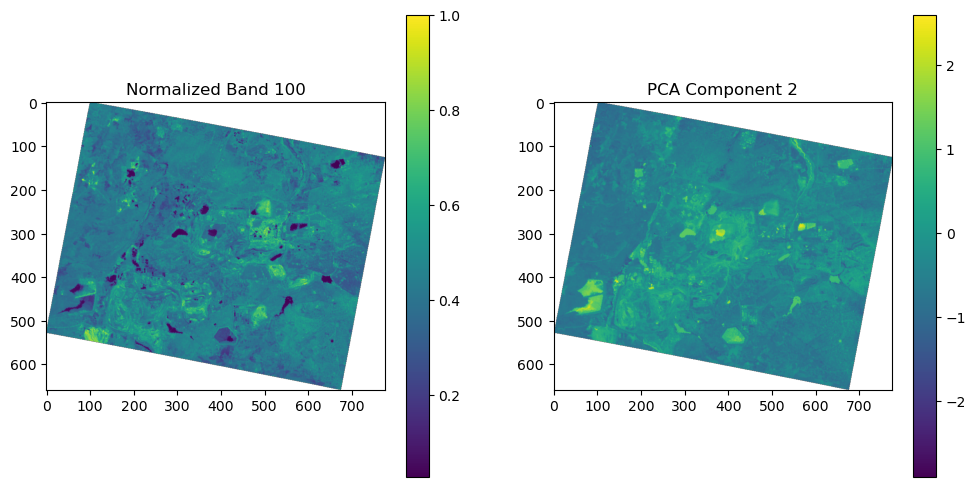

In [8]:
### Last bit of image prep, run a PCA on the normalized image, we'll use those components for the segmentation

# reshape the array so there is 1 column per band
rad_array_reshaped = rad_array_masked.reshape(-1, rad_array_masked.shape[-1]* rad_array_masked.shape[-2]).T

# remove rows with nans
rad_array_reshaped = rad_array_reshaped[~np.isnan(rad_array_reshaped).any(axis=1)]

n_components = 5
pca = PCA(n_components=n_components)
pca.fit(rad_array_reshaped)

# grab the spectra, we need these to reproject the data.
component_spectra = pca.components_

# need to make a new reshaped array to project the data into the PCA space
rad_array_reshaped = rad_array_masked.reshape(-1, rad_array_masked.shape[-1]* rad_array_masked.shape[-2]).T

# multiply the reshaped array by the component spectra to get the scores
rad_pc_scores = rad_array_reshaped @ component_spectra.T

# reshape back into an image
rad_pc_image = rad_pc_scores.T.reshape(n_components, rad_array_masked.shape[1], rad_array_masked.shape[2])

# as a check, print the percentage of variance explained by each component
print("Explained variance ratio:", pca.explained_variance_ratio_)

# and plot one of the bands from the normalized image and the 2nd PCA component
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(rad_array_masked[100], cmap='viridis')
plt.title('Normalized Band 100')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(rad_pc_image[1], cmap='viridis')
plt.title('PCA Component 2')
plt.colorbar()
plt.show()

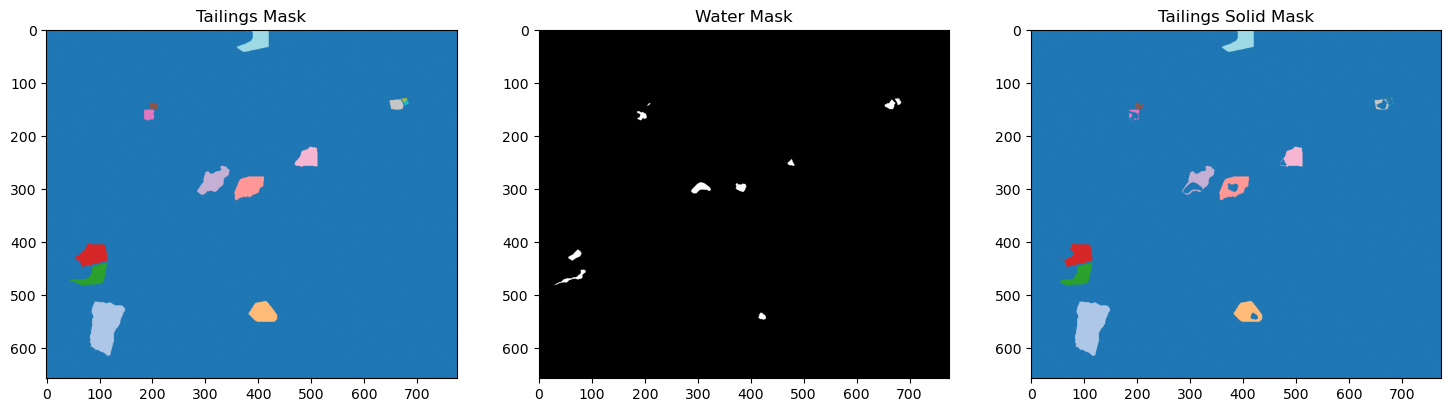

In [9]:
### Prep for segmentation: 
# For the tailings and water shapefiles, rasterize them at the same resolution as the hyperspectral data to create masks

# some custom functions to get geo-referencing info from the metadata
metadata = tanager_file_handling.h5_metadata(scene_file)
georef_info = tanager_file_handling.extract_georef_info(metadata)
ref_transform = tanager_file_handling.build_affine_transform(georef_info)
ref_crs = tanager_file_handling.build_crs(georef_info)
ref_shape = (georef_info['YDim'], georef_info['XDim'])

# double check the CRS of the polygons
if tailings_gdf.crs != ref_crs:
    tailings_gdf = tailings_gdf.to_crs(ref_crs)

if water_gdf.crs != ref_crs:
    water_gdf = water_gdf.to_crs(ref_crs)

# also assign each polygon a unique ID, so we can track them in the rasterized mask
tailings_gdf['id'] = range(1, len(tailings_gdf) + 1)

# rasterize the tailings and water polygons
tailings_mask = rasterize(
    [(geom, value) for geom, value in zip(tailings_gdf.geometry, tailings_gdf.id)],
    out_shape=ref_shape,
    transform=ref_transform,
    fill=0,
    dtype=np.uint8
)
# water mask doesn't need unique IDs, just a binary mask
water_mask = rasterize(
    [(geom, 1) for geom in water_gdf.geometry],
    out_shape=ref_shape,
    transform=ref_transform,
    fill=0,
    dtype=np.uint8
)

# can also make one more mask where any water areas are set to 0 in the tailings mask
tailings_solid_mask = tailings_mask.copy()
tailings_solid_mask[water_mask == 1] = 0


# as an output for this cell, plot all 3 masks to check them
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(tailings_mask, cmap='tab20')
ax[0].set_title('Tailings Mask')
ax[1].imshow(water_mask, cmap='gray')
ax[1].set_title('Water Mask')
ax[2].imshow(tailings_solid_mask, cmap='tab20')
ax[2].set_title('Tailings Solid Mask')
plt.show()

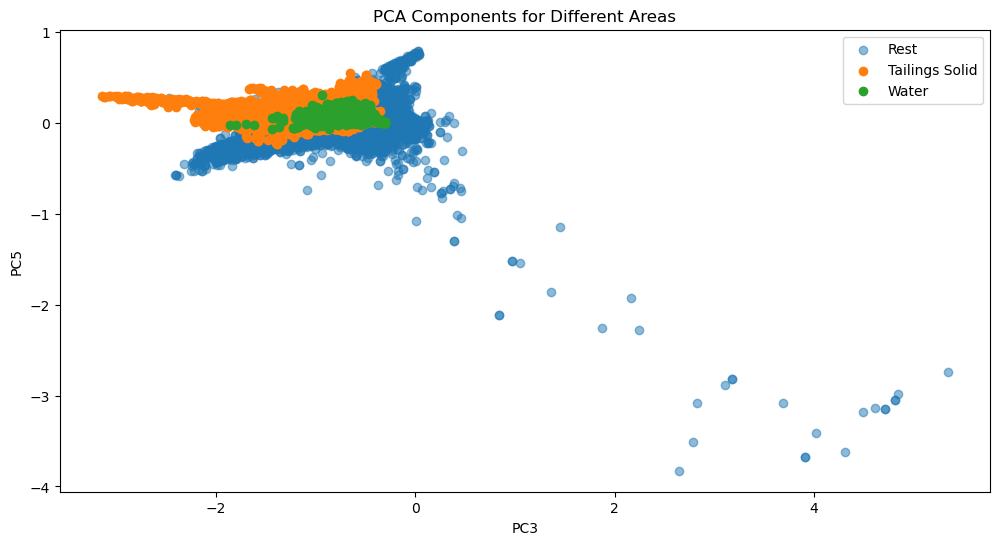

In [21]:
### organize some pixel PC scores so we can think about plotting and segmenting
# we want an array for each discrete tailings area, and one for the water areas, and one for the rest of the image

# first, make a mask for the rest of the image
rest_mask = (tailings_solid_mask == 0) & (water_mask == 0)

# we can do a dict to hold the scores for each area
area_scores = {}
for i in range(1, len(tailings_gdf) + 1):
    area_scores[f'tailings_solid{i}'] = rad_pc_image[:, tailings_solid_mask == i]

# duplicate, but easy for plotting, make one of all tailings solids combined
area_scores['tailings_solid_all'] = rad_pc_image[:, tailings_solid_mask > 0]

# add the water area scores
area_scores['water'] = rad_pc_image[:, water_mask == 1]

# add the rest of the image scores
area_scores['rest'] = rad_pc_image[:, rest_mask]

# can explore more, but as a check, let's plot any 2 PCs for the tailings solid, water, and rest areas
pc_x = 2  # PCA component (0-based index)
pc_y = 4  # PCA component (0-based index)
plt.figure(figsize=(12, 6))
plt.subplot(1, 1, 1)
# plot rest first, so it is in the background, reduce the alpha for better visibility
plt.scatter(area_scores['rest'][pc_x], area_scores['rest'][pc_y], label='Rest', alpha=0.5)
plt.scatter(area_scores['tailings_solid_all'][pc_x], area_scores['tailings_solid_all'][pc_y], label='Tailings Solid')
plt.scatter(area_scores['water'][pc_x], area_scores['water'][pc_y], label='Water')
plt.xlabel('PC' + str(pc_x + 1))
plt.ylabel('PC' + str(pc_y + 1))
plt.legend()
plt.title('PCA Components for Different Areas')
plt.show()


In [ ]:
### a set of pixels have really high PC 3 and PC 5 values, plot those images to see where they are located

# define thresholds for PC 3 and PC 5
pc3_threshold = 0.7 # greater than this value
pc5_threshold = -1 # less than this value

# how many pixels meet each criterion and both?
pc3_mask = rad_pc_image[2] > pc3_threshold
pc5_mask = rad_pc_image[4] < pc5_threshold
both_mask = pc3_mask & pc5_mask

print(f"Pixels with PC 3 > {pc3_threshold}: {np.sum(pc3_mask)}")
print(f"Pixels with PC 5 < {pc5_threshold}: {np.sum(pc5_mask)}")
print(f"Pixels meeting both criteria: {np.sum(both_mask)}") 


Pixels with PC 3 > 0.7: 29
Pixels with PC 5 < -1: 34
Pixels meeting both criteria: 29


# Conclusion about high PC3, low PC5 pixels

After manually investigating higher spatial resolution imagery of those spots, I cannot find any physical signatures of interest at those spots. I'm left to assume they are some small wispy clouds. Anyways, they aren't on mining sites, so not following this lead for now. Also note that very high PC 5 scores appear to represent a very recent solar panel installatio at Musonoi.

Pixels with PC 3 < -2: 377
Pixels with PC 5 > 0.1: 28817
Pixels meeting both criteria: 192


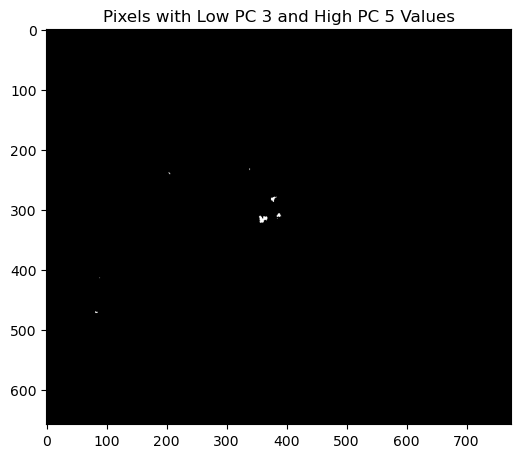

In [25]:
### What about low pc3 and high pc5 values?
# define thresholds for PC 3 and PC 5
pc3_threshold = -2 # less than this value
pc5_threshold = 0.1 # greater than this value

# how many pixels meet each criterion and both?
pc3_mask = rad_pc_image[2] < pc3_threshold
pc5_mask = rad_pc_image[4] > pc5_threshold
both_mask = pc3_mask & pc5_mask
print(f"Pixels with PC 3 < {pc3_threshold}: {np.sum(pc3_mask)}")
print(f"Pixels with PC 5 > {pc5_threshold}: {np.sum(pc5_mask)}")
print(f"Pixels meeting both criteria: {np.sum(both_mask)}")

# show the both mask
plt.figure(figsize=(6, 6))
plt.imshow(both_mask, cmap='gray')
plt.title('Pixels with Low PC 3 and High PC 5 Values')
plt.show()

Text(0, 0.5, 'Component Loading')

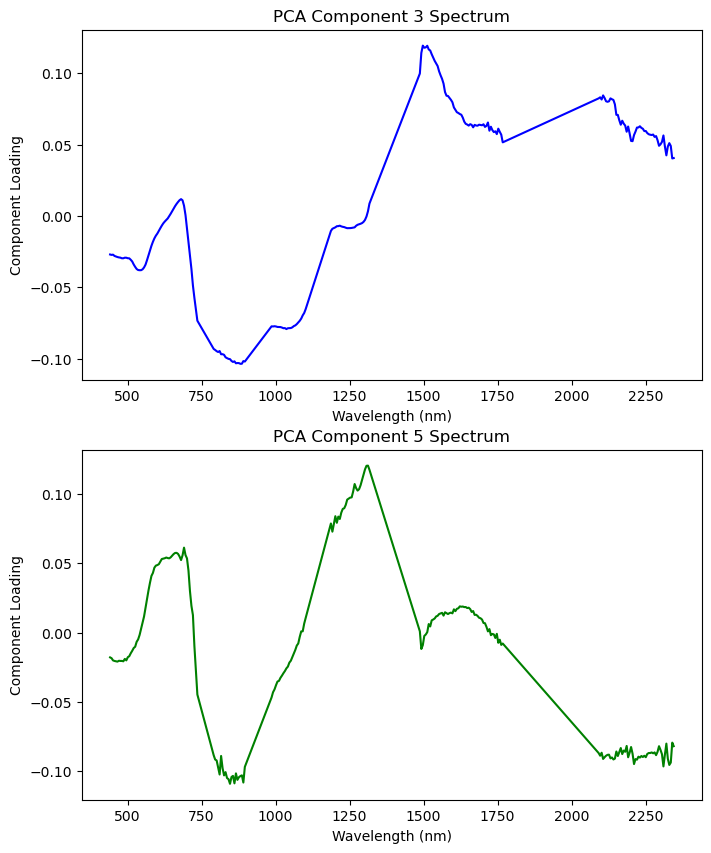

In [ ]:
### Those pixels are clearly distinct tailings materials. What are the pc 3 and 5 spectra like?

# 2 subplots in one column
fig, ax = plt.subplots(2, 1, figsize=(8, 10))
ax[0].plot(wavelengths_masked, component_spectra[2], color='blue')
ax[0].set_title('PCA Component 3 Spectrum')
ax[0].set_xlabel('Wavelength (nm)')
ax[0].set_ylabel('Component Loading')
ax[1].plot(wavelengths_masked, component_spectra[4], color='green')
ax[1].set_title('PCA Component 5 Spectrum')
ax[1].set_xlabel('Wavelength (nm)')
ax[1].set_ylabel('Component Loading')   

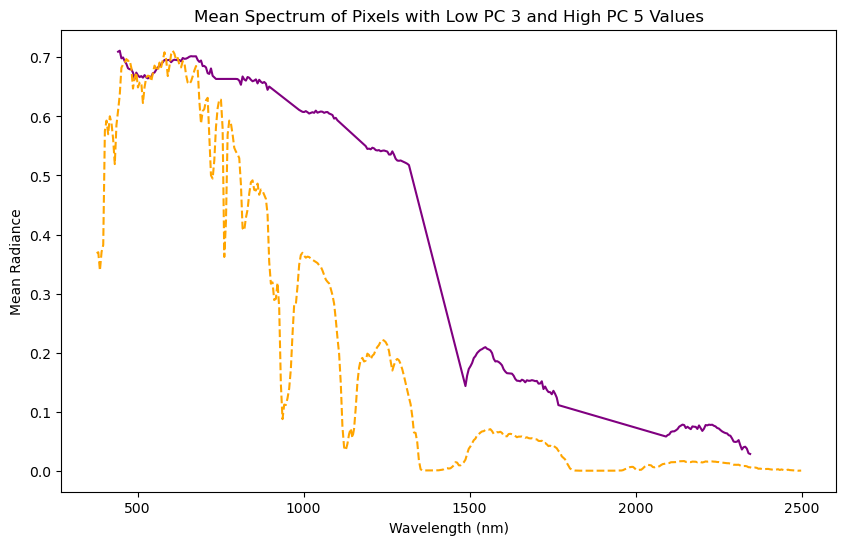

In [29]:
### and plot the mean spectrum of those pixels

both_pixels_spectra = rad_array_masked[:, both_mask]
mean_both_spectrum = np.nanmean(both_pixels_spectra, axis=1)

# also get from the original rad array for comparison
both_pixels_spectra_orig = rad_array[:, both_mask]
mean_both_spectrum_orig = np.nanmean(both_pixels_spectra_orig, axis=1)
# normalize the original mean spectrum for better comparison
mean_both_spectrum_orig = mean_both_spectrum_orig / np.nanmax(mean_both_spectrum_orig) * np.nanmax(mean_both_spectrum)

plt.figure(figsize=(10, 6))
plt.plot(wavelengths_masked, mean_both_spectrum, color='purple')
plt.plot(rad_attrs['wavelengths'], mean_both_spectrum_orig, color='orange', linestyle='--', label='Original Mean Spectrum')
plt.title('Mean Spectrum of Pixels with Low PC 3 and High PC 5 Values')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Mean Radiance')
plt.show()